# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, I compare the performance of these classifiers: K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  The dataset used is related to marketing bank products over the telephone.



### Getting Started

The dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  This article accompanied the dataset [here](CRISP-DM-BANK.pdf)



### Problem 1: Understanding the Data

To gain a better understanding of the data, I read the information provided in the UCI link above, and examined the **Materials and Methods** section of the paper.  For example, how many marketing campaigns did this data represent?

**Answer:** 17

### Problem 2: Read in the Data

I used pandas to read in the dataset `bank-additional-full.csv` .

In [1]:
# load in the initial set of packages to be used for analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC



In [2]:
#get paths to setup links to plots in image folder
import os
os.getcwd()


'/Users/jeffreylgoode/Documents/marketing-classifier-comparison/notebooks'

In [3]:
# set up the dataframe
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')


In [4]:
# review the data
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

There are 20 feature columns, 1 target column, 41188 rows

### Problem 3: Understanding the Features


The data descriptions are below, first we determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
# check for missing values
df.isna().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

There were no missing values.

In [7]:
df.dtypes


age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Categories are stored as object, numeric columns are in or float, no datetime columns, several str columns, no booleans.

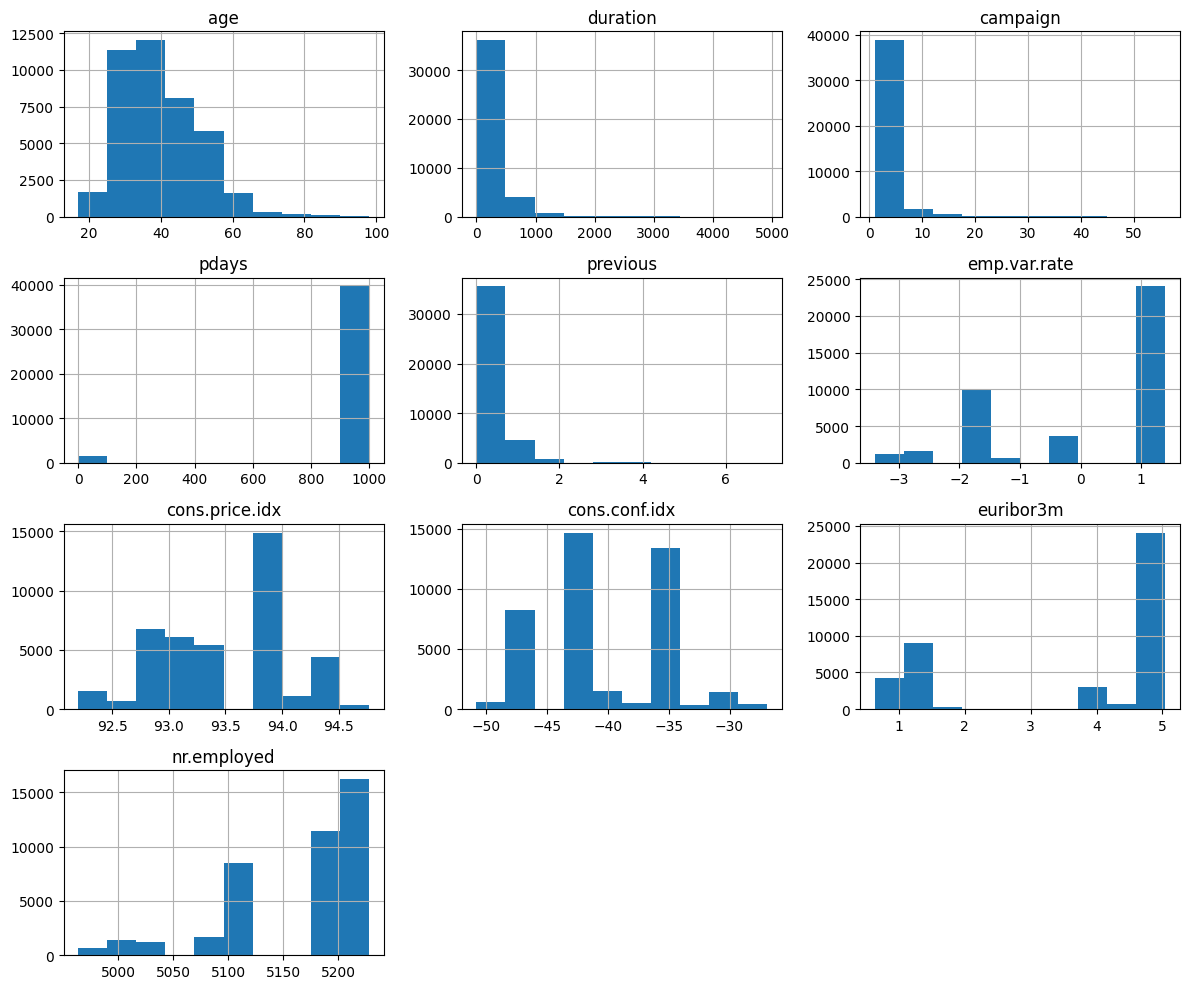

In [8]:
#Let's visualize the data
df.select_dtypes(include=['int64','float64']).hist(figsize=(12,10))
plt.tight_layout()
plt.show()


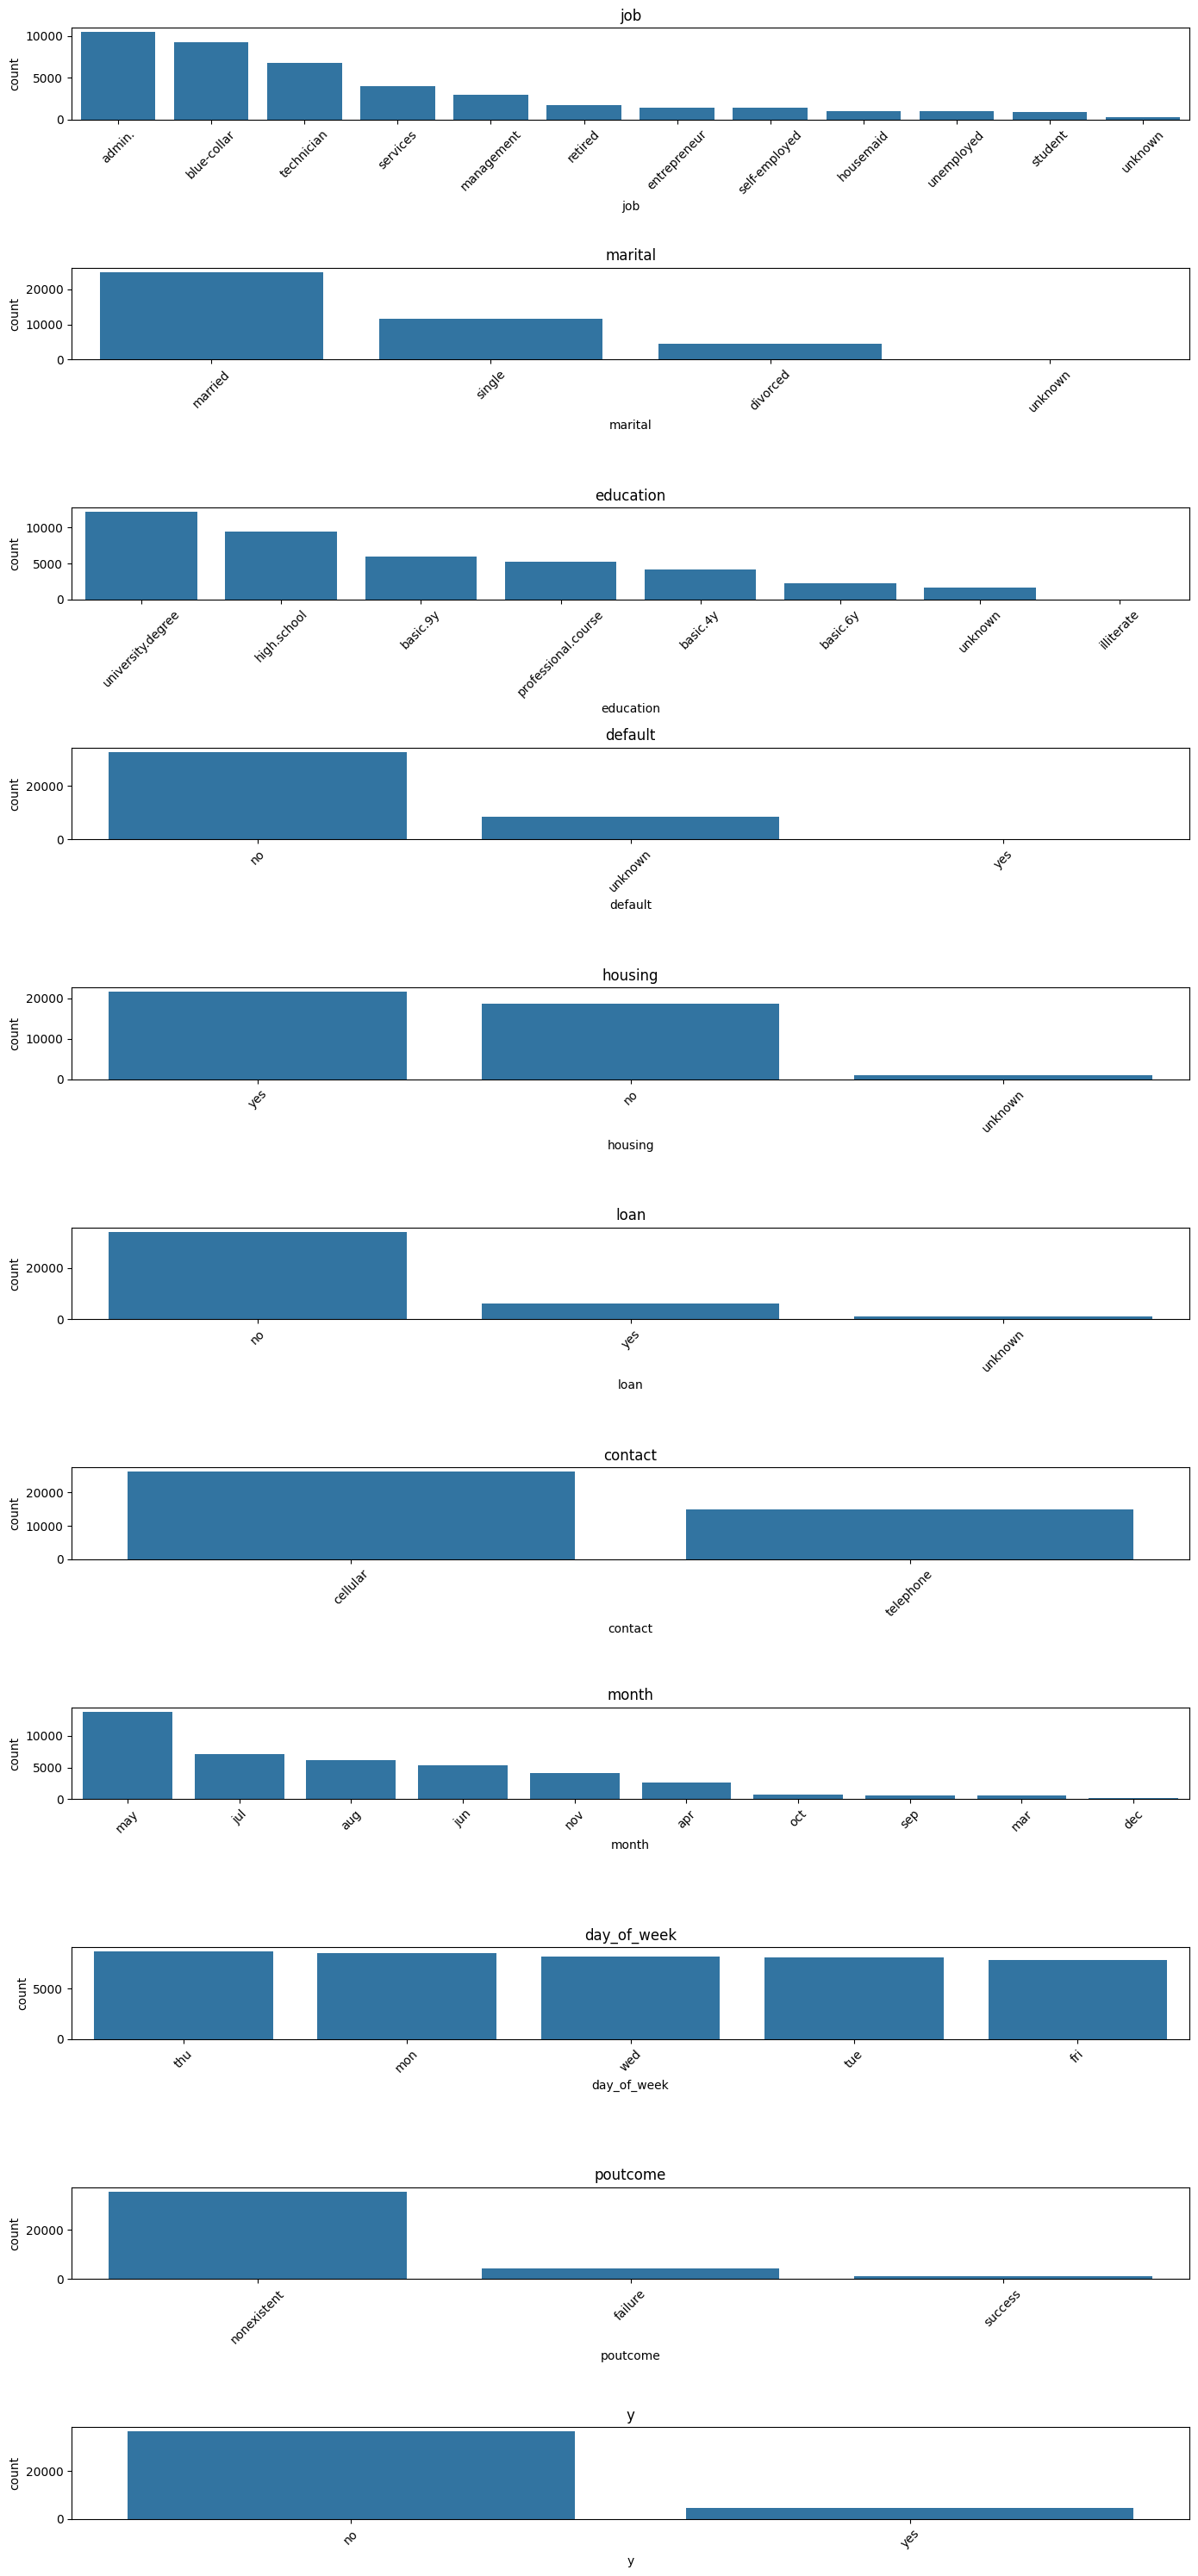

In [88]:
# now visualize category data
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

plt.figure(figsize=(14, 30))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


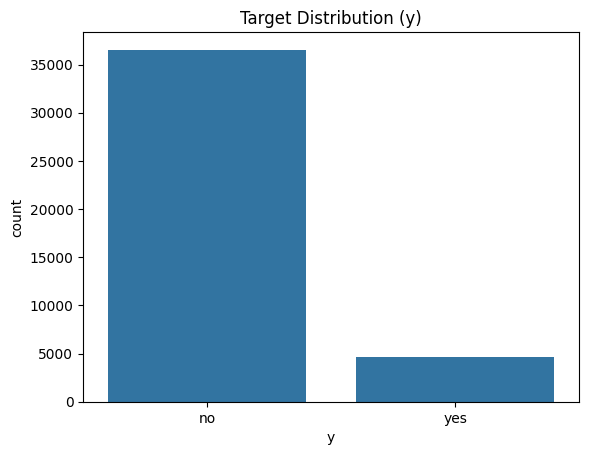

In [89]:
#Visualize target variable
sns.countplot(data=df, x='y')
plt.title("Target Distribution (y)")
plt.show()


In [9]:
df["y"].value_counts(normalize=True) * 100


y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

**Given that the subscribe = no, versus yes is unbalanced, we need to think about which classifiers perform better with unbalanced datasets**.

Now explore data using correlations

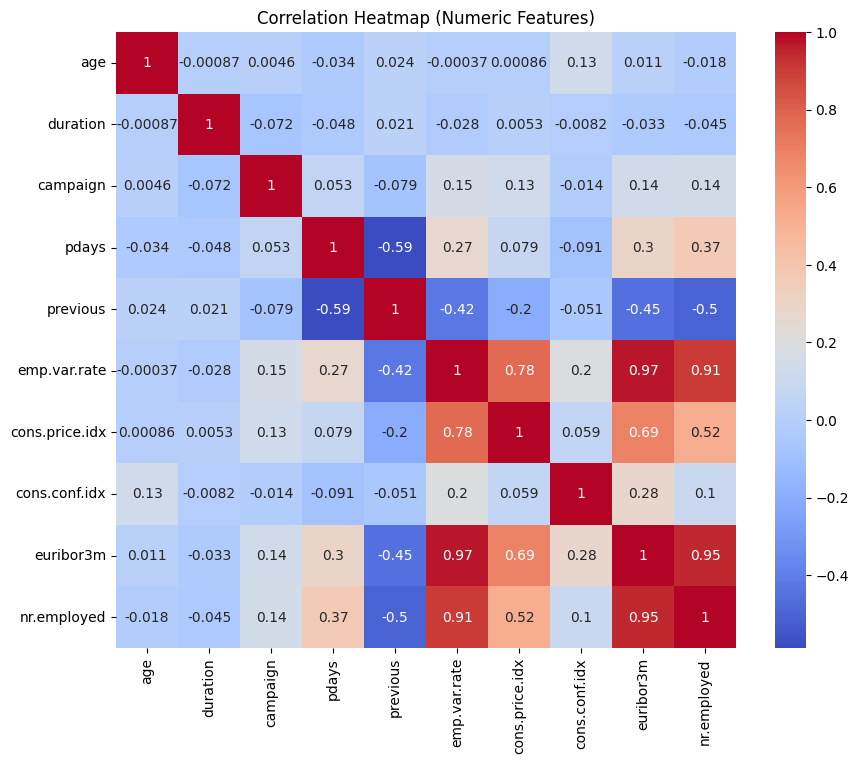

In [90]:
# visualize correlation heat map
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


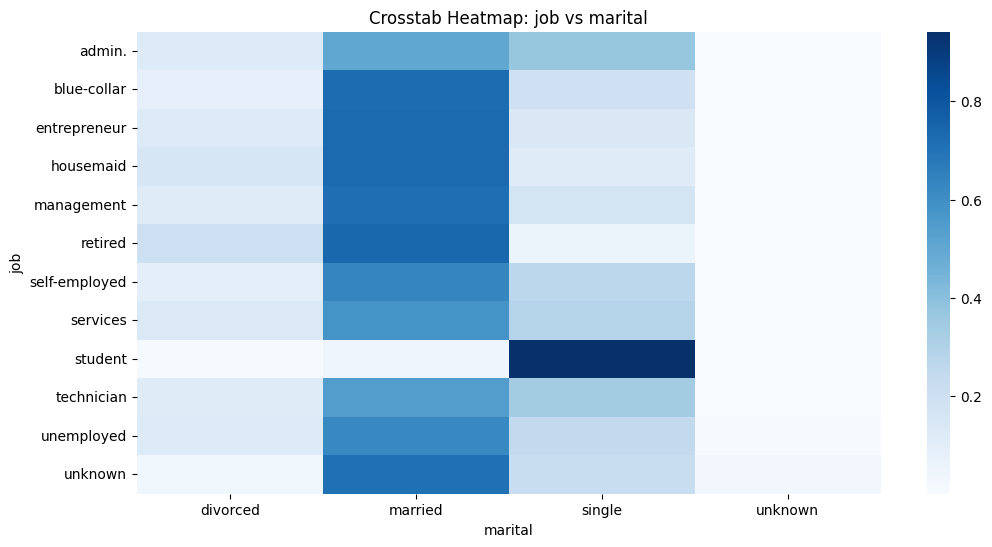

In [91]:
# job vs marital status
ct = pd.crosstab(df['job'], df['marital'], normalize='index')

plt.figure(figsize=(12, 6))
sns.heatmap(ct, cmap='Blues', annot=False)
plt.title("Crosstab Heatmap: job vs marital")
plt.show()


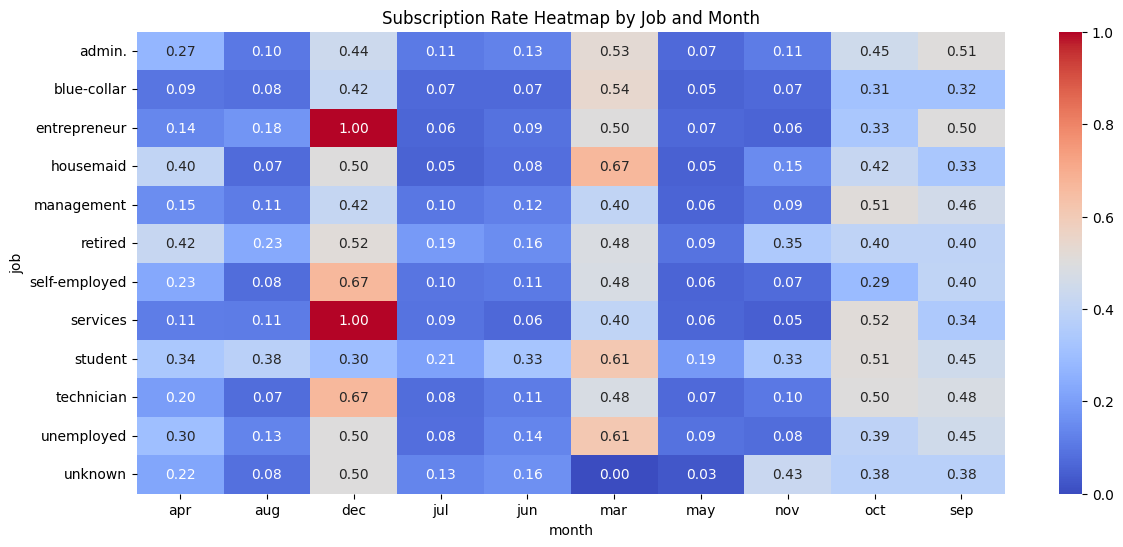

In [92]:
#subscription rate by job and month
target_rate = pd.crosstab(df['job'], df['month'],
                          values=(df['y'] == 'yes').astype(int),
                          aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(target_rate, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Subscription Rate Heatmap by Job and Month")
plt.show()


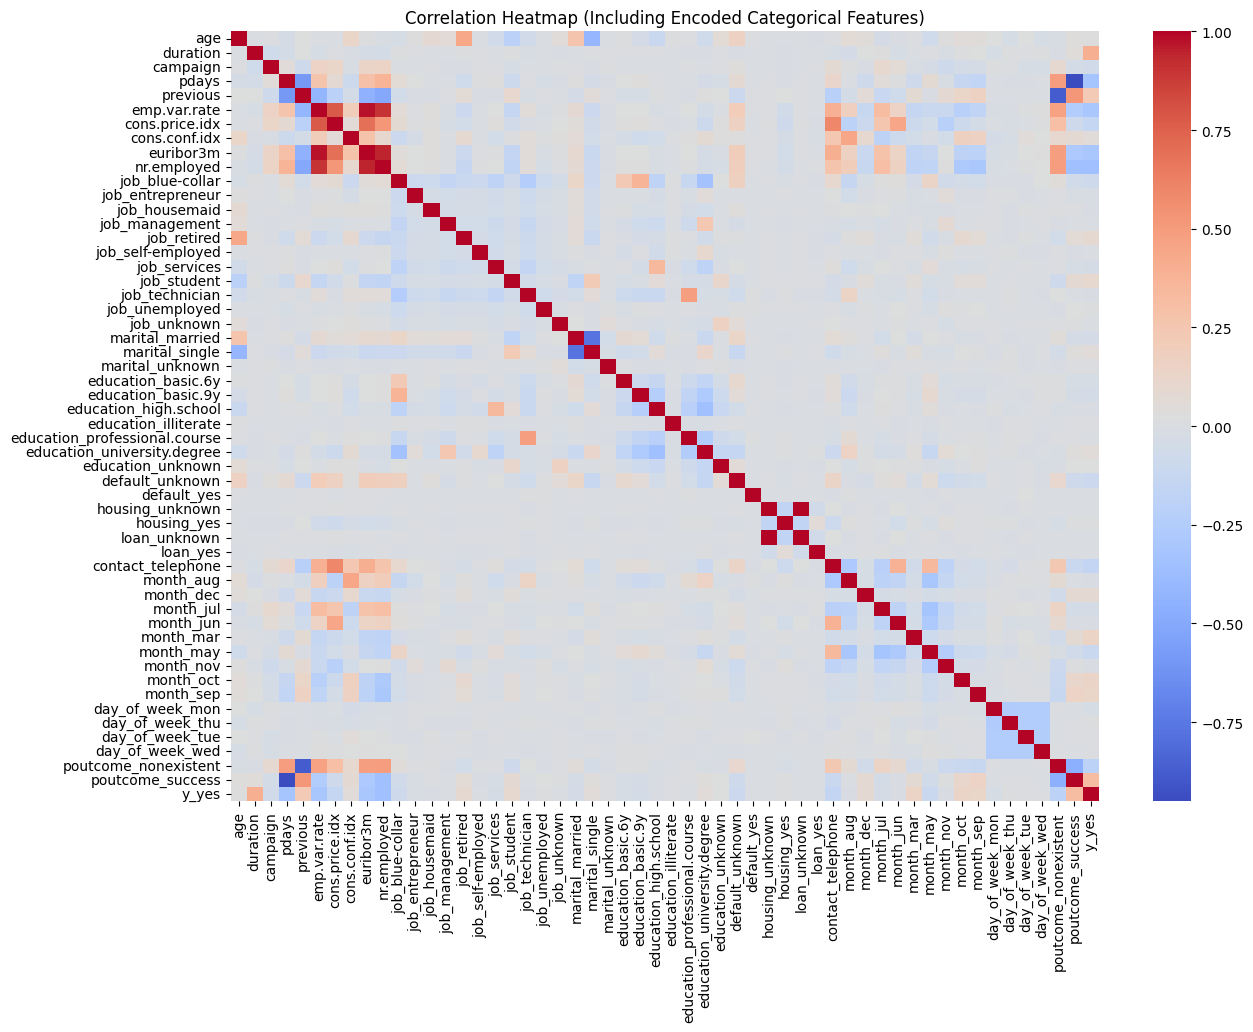

In [93]:
#interesting but very busy, not as insightful as hoped
df_encoded = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Including Encoded Categorical Features)")
plt.show()


### Problem 4: Understanding the Task

After examining the description and data, our goal now is to clearly state the *Business Objective* of the task.  The business objective is stated below:

**Which customers should we target in our marketing campaign to maximize term‑deposit subscriptions?**

Answering this question will allow us to predict which customers are most likely to say "Yes" to the a term deposit.


### Problem 5: Engineering Features

Given our business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data and prepare the features and target column for modeling with appropriate encoding and transformations.

In [10]:
# --- 1. Separate X and y ---
X = df.drop("y", axis=1)
y = df["y"].map({"yes": 1, "no": 0})

In [11]:
# --- 2. Identify column types ---
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [12]:
# --- 3. Preprocessing ---
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

### Problem 6: Train/Test Split

Now se split the data into a train and test set.

In [13]:
# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Problem 7: A Baseline Model and Model Comparison Metrics

Before we build our first model, we want to establish a baseline, the baseline performance that our classifier should aim to beat.

In [98]:
df["y"].value_counts(normalize=True) * 100


y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

The baseline performance we are wanting to beat is "always predict the majority class".  In this case the majority class is **NO**.

In [99]:
print(f"Percent no: {df['y'].value_counts(normalize=True)['no'] * 100:.2f}%")


Percent no: 88.73%


Practically speaking, if we predict the majority class of **NO**, we will be right **88.73%** of the time.  We can therefore set as a goal that our selected model accuracy should be at least as good as the baseline.

In addition to accuracy, we will compare models using:
* Precision/recall
* Confusion Matrix
* Receiver Operating Charactistics (ROC) curve
* Area under the ROC curve (AOC)

### Problem 8: A Simple Model

We will start with a Logistic Regression model.

In [14]:
# --- 5. Use Logistic Regression ---
log_reg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])
log_reg_model.fit(X_train, y_train)
log_reg_preds = log_reg_model.predict(X_test)

### Problem 9: Score the Model

We will assess accuracy, precision/recall, the confusion matrix, ROC and AOC.

In [18]:
# --- 6. Score the Logistic Regression model ---
log_reg_acc = accuracy_score(y_test, log_reg_preds)
print(f"Logistic Regression Accuracy: {log_reg_acc:.4f}")

Logistic Regression Accuracy: 0.9151


**The accuracy of the model is 91.51%**

Precision (1): 0.701
Recall (1):    0.430


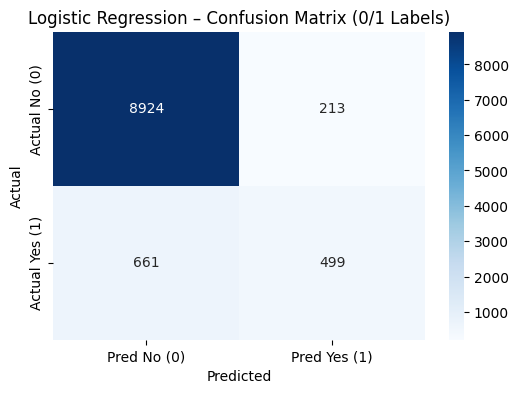

AUC: 0.942


<Figure size 600x400 with 0 Axes>

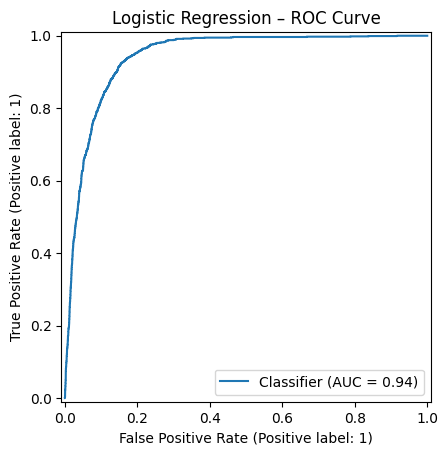

In [21]:
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix,
    RocCurveDisplay, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Predictions ---
log_reg_preds = log_reg_model.predict(X_test)
log_reg_probs = log_reg_model.predict_proba(X_test)[:, 1]  # probability of class 1 ("Yes")

# --- 2. Precision & Recall (positive class = 1) ---
precision = precision_score(y_test, log_reg_preds, pos_label=1)
recall = recall_score(y_test, log_reg_preds, pos_label=1)

print(f"Precision (1): {precision:.3f}")
print(f"Recall (1):    {recall:.3f}")

# --- 3. Confusion Matrix ---
cm = confusion_matrix(y_test, log_reg_preds, labels=[0, 1])

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No (0)', 'Pred Yes (1)'],
    yticklabels=['Actual No (0)', 'Actual Yes (1)']
)
plt.title("Logistic Regression – Confusion Matrix (0/1 Labels)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 4. ROC Curve & AUC ---
auc = roc_auc_score(y_test, log_reg_probs)
print(f"AUC: {auc:.3f}")

plt.figure(figsize=(6,4))
RocCurveDisplay.from_predictions(y_test, log_reg_probs)
plt.title("Logistic Regression – ROC Curve")
plt.show()


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [102]:
import time
import pandas as pd

# Define the models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf")
}

results = []

for name, model in models.items():
    # Build pipeline for each model
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    # Measure training time
    start = time.time()
    pipe.fit(X_train, y_train)
    end = time.time()

    train_time = end - start
    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)

    results.append([name, train_time, train_acc, test_acc])

# Convert to DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Time", "Train Accuracy", "Test Accuracy"]
)

results_df


,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.078070,0.910233,0.915121
1,Decision Tree,0.160221,1.000000,0.887346
2,KNN (k=5),0.035591,0.927649,0.905409
3,SVM (RBF),4.378789,0.922307,0.913664


![Model Comparison](../images/first_model_comparison.png)

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [103]:
# Let's tune the LR model
from sklearn.model_selection import GridSearchCV

lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 0.5, 1],   # 0=L2, 1=L1, 0.5=elastic net
}

lr_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            solver="saga",          # supports elastic net
            max_iter=5000
        ))
    ]),
    param_grid=lr_params,
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR test accuracy:", lr_grid.score(X_test, y_test))


Best LR params: {'model__C': 10, 'model__l1_ratio': 0}
Best LR test accuracy: 0.914829562008352


In [104]:
# now let's tune the decision tree
from sklearn.model_selection import GridSearchCV

tree_params = {
    "model__max_depth": [3, 5, 7, 9, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["gini", "entropy"]
}

tree_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    param_grid=tree_params,
    cv=5,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree params:", tree_grid.best_params_)
print("Best Decision Tree test accuracy:", tree_grid.score(X_test, y_test))


Best Decision Tree params: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best Decision Tree test accuracy: 0.9171603379625134


In [105]:
#now let's tune KNN
from sklearn.model_selection import GridSearchCV

knn_params = {
    "model__n_neighbors": list(range(1, 31, 2)),   # odd values 1–29
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan vs Euclidean
}

knn_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier())
    ]),
    param_grid=knn_params,
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN params:", knn_grid.best_params_)
print("Best KNN test accuracy:", knn_grid.score(X_test, y_test))


Best KNN params: {'model__n_neighbors': 23, 'model__p': 2, 'model__weights': 'distance'}
Best KNN test accuracy: 0.9099737787705157


In [106]:
#now let's tune SVM (RBF)
from sklearn.model_selection import GridSearchCV

svm_params = {
    "model__C": [1, 10, 100],
    "model__gamma": [0.01, 0.1],
    "model__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", SVC())
    ]),
    param_grid=svm_params,
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM params:", svm_grid.best_params_)
print("Best SVM test accuracy:", svm_grid.score(X_test, y_test))


Best SVM params: {'model__C': 1, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Best SVM test accuracy: 0.9125959017189472


**Below is the accuracy results of the tuned models.**

![Model Comparison](../images/tuned_model_comparison.png)

### Problem 12: Answering the Business Question, Findings, Next Steps and Recommendations



Let's answer the business question.

**Which customers should we target in our marketing campaign to maximize term‑deposit subscriptions?**

Answering this question will allow us to predict which customers are most likely to say "Yes" to the a term deposit.

In [107]:
best_lr = lr_grid.best_estimator_
ct = best_lr.named_steps["preprocess"]
ohe = ct.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(encoded_cat_cols) + numeric_cols
lr_model = best_lr.named_steps["model"]

import pandas as pd
import numpy as np

lr_importance = pd.DataFrame({
    "feature": all_feature_names,
    "coef": lr_model.coef_.flatten()
})

lr_importance["abs_coef"] = lr_importance["coef"].abs()
lr_top = lr_importance.sort_values("abs_coef", ascending=False)

lr_top.head(15)
print("\nTop 15 Logistic Regression Predictors:\n")
print(lr_top.head(15).to_string(index=False))



Top 15 Logistic Regression Predictors:

             feature      coef  abs_coef
        emp.var.rate -2.746292  2.746292
           month_mar  1.691160  1.691160
      cons.price.idx  1.238963  1.238963
            duration  1.209129  1.209129
           month_jun -0.854096  0.854096
           month_may -0.751312  0.751312
           month_nov -0.746765  0.746765
           euribor3m  0.716502  0.716502
   contact_telephone -0.657829  0.657829
    poutcome_failure -0.628100  0.628100
education_illiterate  0.607588  0.607588
           month_aug  0.569758  0.569758
     default_unknown -0.449776  0.449776
         job_retired  0.312159  0.312159
  education_basic.9y -0.309312  0.309312


Let's rerun to simply with the top 6 predictors.

In [108]:
# Select only the strongest predictors
selected_features = [
    "duration",
    "cons.price.idx",
    "euribor3m",
    "month",        # we will one-hot encode this
    "job",          # for retired
    "emp.var.rate"  # keep because it's extremely strong
]

X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]


In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Identify categorical and numeric columns
reduced_cat = ["month", "job"]
reduced_num = ["duration", "cons.price.idx", "euribor3m", "emp.var.rate"]

reduced_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), reduced_cat),
    ("num", StandardScaler(), reduced_num)
])

reduced_lr_pipe = Pipeline([
    ("preprocess", reduced_preprocess),
    ("model", LogisticRegression(max_iter=5000))
])

reduced_lr_pipe.fit(X_train_reduced, y_train)

reduced_accuracy = reduced_lr_pipe.score(X_test_reduced, y_test)
print("Reduced model accuracy:", reduced_accuracy)


Reduced model accuracy: 0.9061862678450034


Now let's run the Decision Tree with the reduced set of features

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

reduced_cat = ["month", "job"]
reduced_num = ["duration", "cons.price.idx", "euribor3m", "emp.var.rate"]

reduced_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), reduced_cat),
    ("num", "passthrough", reduced_num)
])


In [111]:
dt_reduced = Pipeline([
    ("preprocess", reduced_preprocess),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42
    ))
])

dt_reduced.fit(X_train_reduced, y_train)

dt_reduced_accuracy = dt_reduced.score(X_test_reduced, y_test)
print("Reduced Decision Tree accuracy:", dt_reduced_accuracy)


Reduced Decision Tree accuracy: 0.9085170437991648


Now let's re run with timing and accuracy and hyper parameters, LR first.

In [112]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Reduced feature set
selected_features = [
    "duration",
    "cons.price.idx",
    "euribor3m",
    "emp.var.rate",
    "month",
    "job"
]

X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

# Preprocessing
reduced_cat = ["month", "job"]
reduced_num = ["duration", "cons.price.idx", "euribor3m", "emp.var.rate"]

reduced_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), reduced_cat),
    ("num", StandardScaler(), reduced_num)
])

# Logistic Regression hyperparameters used:
# solver='lbfgs' (default), max_iter=5000
reduced_lr_pipe = Pipeline([
    ("preprocess", reduced_preprocess),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs"
    ))
])

# Timing + training
start = time.time()
reduced_lr_pipe.fit(X_train_reduced, y_train)
end = time.time()

train_time_lr = end - start
train_acc_lr = accuracy_score(y_train, reduced_lr_pipe.predict(X_train_reduced))
test_acc_lr = accuracy_score(y_test, reduced_lr_pipe.predict(X_test_reduced))

print("Reduced Logistic Regression (Hyperparameters: solver='lbfgs', max_iter=5000)")
print(f"Train time: {train_time_lr:.4f} seconds")
print(f"Train accuracy: {train_acc_lr:.4f}")
print(f"Test accuracy: {test_acc_lr:.4f}")


Reduced Logistic Regression (Hyperparameters: solver='lbfgs', max_iter=5000)
Train time: 0.0372 seconds
Train accuracy: 0.9050
Test accuracy: 0.9062


Now let's do the same for Decision Tree.

In [113]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Reuse reduced feature set
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

# Preprocessing (DT does not need scaling)
reduced_preprocess_dt = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), reduced_cat),
    ("num", "passthrough", reduced_num)
])

# Decision Tree hyperparameters used:
# criterion='gini', max_depth=5, min_samples_leaf=4, min_samples_split=2
dt_reduced_pipe = Pipeline([
    ("preprocess", reduced_preprocess_dt),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42
    ))
])

# Timing + training
start = time.time()
dt_reduced_pipe.fit(X_train_reduced, y_train)
end = time.time()

train_time_dt = end - start
train_acc_dt = accuracy_score(y_train, dt_reduced_pipe.predict(X_train_reduced))
test_acc_dt = accuracy_score(y_test, dt_reduced_pipe.predict(X_test_reduced))

print("Reduced Decision Tree (Hyperparameters: criterion='gini', max_depth=5, min_samples_leaf=4, min_samples_split=2)")
print(f"Train time: {train_time_dt:.4f} seconds")
print(f"Train accuracy: {train_acc_dt:.4f}")
print(f"Test accuracy: {test_acc_dt:.4f}")


Reduced Decision Tree (Hyperparameters: criterion='gini', max_depth=5, min_samples_leaf=4, min_samples_split=2)
Train time: 0.0337 seconds
Train accuracy: 0.9131
Test accuracy: 0.9085


![Model Comparison](../images/reduced_feature_tuned.png)

Now let's print the confusion matrices.

Reduced Logistic Regression Confusion Matrix (labels=[1,0]):
[[ 437  723]
 [ 243 8894]]

Reduced Decision Tree Confusion Matrix (labels=[1,0]):
[[ 546  614]
 [ 328 8809]]


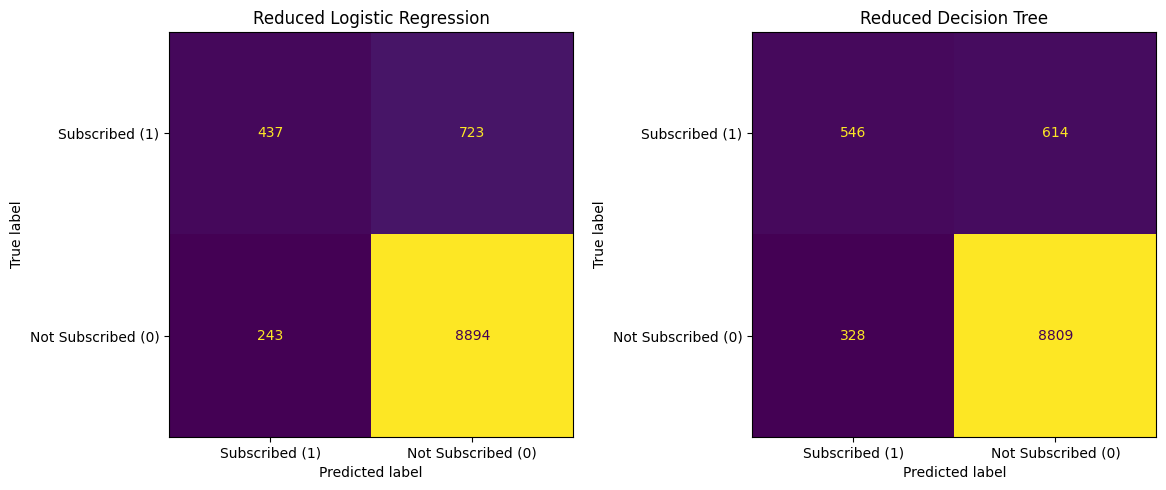

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
lr_pred = reduced_lr_pipe.predict(X_test_reduced)
dt_pred = dt_reduced_pipe.predict(X_test_reduced)

# Confusion matrices
lr_cm = confusion_matrix(y_test, lr_pred, labels=[1, 0])
dt_cm = confusion_matrix(y_test, dt_pred, labels=[1, 0])

print("Reduced Logistic Regression Confusion Matrix (labels=[1,0]):")
print(lr_cm)

print("\nReduced Decision Tree Confusion Matrix (labels=[1,0]):")
print(dt_cm)

# Optional: side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(lr_cm, display_labels=['Subscribed (1)', 'Not Subscribed (0)']).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Reduced Logistic Regression")

ConfusionMatrixDisplay(dt_cm, display_labels=['Subscribed (1)', 'Not Subscribed (0)']).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Reduced Decision Tree")

plt.tight_layout()
plt.show()


Let's have a look at the coefficients again for the reduced features.

In [115]:
# Extract the ColumnTransformer
ct_lr = reduced_lr_pipe.named_steps["preprocess"]

# Extract the OneHotEncoder for categorical features
ohe_lr = ct_lr.named_transformers_["cat"]

# Get the encoded categorical feature names
encoded_cat_lr = ohe_lr.get_feature_names_out(["month", "job"])

# Combine with numeric features
reduced_feature_names_lr = list(encoded_cat_lr) + reduced_num

print("Expanded LR feature names:")
for f in reduced_feature_names_lr:
    print(f)


Expanded LR feature names:
month_apr
month_aug
month_dec
month_jul
month_jun
month_mar
month_may
month_nov
month_oct
month_sep
job_admin.
job_blue-collar
job_entrepreneur
job_housemaid
job_management
job_retired
job_self-employed
job_services
job_student
job_technician
job_unemployed
job_unknown
duration
cons.price.idx
euribor3m
emp.var.rate


In [116]:
lr_coefs = reduced_lr_pipe.named_steps["model"].coef_.flatten()

for name, coef in zip(reduced_feature_names_lr, lr_coefs):
    print(f"{name:20s}  {coef:.4f}")


month_apr             -0.6284
month_aug             0.5118
month_dec             -0.0385
month_jul             -0.1265
month_jun             -0.9001
month_mar             1.2468
month_may             -1.1498
month_nov             -0.6843
month_oct             -0.2811
month_sep             -0.0456
job_admin.            -0.0733
job_blue-collar       -0.5093
job_entrepreneur      -0.4005
job_housemaid         -0.2578
job_management        -0.1290
job_retired           0.1320
job_self-employed     -0.4274
job_services          -0.3130
job_student           0.1392
job_technician        -0.1384
job_unemployed        -0.1439
job_unknown           0.0258
duration              1.2116
cons.price.idx        0.9429
euribor3m             0.4101
emp.var.rate          -2.1878


Let's look at feature importance for both models, side by side.

In [117]:
import os
import pandas as pd
import numpy as np

# --- 0. Ensure ../data folder exists ---
data_path = "../data"
if not os.path.exists(data_path):
    os.makedirs(data_path)
    print("Created '../data/' folder.")

# --- 1. Extract expanded feature names for both models ---

# Logistic Regression
ct_lr = reduced_lr_pipe.named_steps["preprocess"]
ohe_lr = ct_lr.named_transformers_["cat"]
encoded_cat_lr = ohe_lr.get_feature_names_out(["month", "job"])
reduced_feature_names_lr = list(encoded_cat_lr) + reduced_num

# Decision Tree
ct_dt = dt_reduced_pipe.named_steps["preprocess"]
ohe_dt = ct_dt.named_transformers_["cat"]
encoded_cat_dt = ohe_dt.get_feature_names_out(["month", "job"])
reduced_feature_names_dt = list(encoded_cat_dt) + reduced_num

# Sanity check
assert reduced_feature_names_lr == reduced_feature_names_dt, "Feature name mismatch!"

feature_names = reduced_feature_names_lr

# --- 2. Extract LR coefficients ---
lr_coefs = reduced_lr_pipe.named_steps["model"].coef_.flatten()
lr_abs = np.abs(lr_coefs)

# --- 3. Extract DT importances ---
dt_importances = dt_reduced_pipe.named_steps["model"].feature_importances_

# --- 4. Build combined DataFrame ---
df_compare = pd.DataFrame({
    "feature": feature_names,
    "lr_coef": lr_coefs,
    "lr_abs": lr_abs,
    "dt_importance": dt_importances
})

# --- 5. Sort by LR coefficient ---
df_compare_sorted = df_compare.sort_values("lr_coef", ascending=False)

# --- 6. Print nicely ---
print(df_compare_sorted.to_string(index=False))

# --- 7. Save to CSV inside ../data/ folder ---
csv_path = "../data/reduced_model_feature_comparison.csv"
df_compare_sorted.to_csv(csv_path, index=False)

print(f"\nCSV saved to: {csv_path}")


          feature   lr_coef   lr_abs  dt_importance
        month_mar  1.246757 1.246757       0.028388
         duration  1.211629 1.211629       0.548158
   cons.price.idx  0.942920 0.942920       0.026203
        month_aug  0.511847 0.511847       0.000000
        euribor3m  0.410053 0.410053       0.339015
      job_student  0.139227 0.139227       0.000000
      job_retired  0.132010 0.132010       0.000000
      job_unknown  0.025849 0.025849       0.000000
        month_dec -0.038480 0.038480       0.000000
        month_sep -0.045624 0.045624       0.000000
       job_admin. -0.073334 0.073334       0.000000
        month_jul -0.126546 0.126546       0.000000
   job_management -0.129038 0.129038       0.000402
   job_technician -0.138426 0.138426       0.000000
   job_unemployed -0.143891 0.143891       0.000000
    job_housemaid -0.257804 0.257804       0.000000
        month_oct -0.281050 0.281050       0.000000
     job_services -0.312958 0.312958       0.000000
 job_entrepr

![Model Comparison](../images/LR_feature_analysis.png)

**Summary**.  A Logistic Regression (LR) model is recommended using 6 features.   The table above summarizes how the marketing department can deploy a campaign for best results, those areas that influence the purchase decision positively and negatively.  The LR model using these features has as accuracy of 90.62%.  The LR model was chosen over the Decision Tree model since it's coefficient directions (positive and negative) were more interpretable and actionable by a marketing department (i.e. not just the importance of month over some other feature, but which months are positive, which are negative).

The reduced feature set LR model is accurate at identifying which customers will not describe, but it struggles to detect customers that will subscribe:

* It correctly identifies 8894 non‑subscribers, with relatively few false positives (243).
* However, it misses 723 actual subscribers, meaning it under‑predicts the “Yes” class.
* This produces a model that is conservative: it avoids over‑calling “Yes,” but at the cost of many missed opportunities.

**Recommended next steps.** Explore other models that are outside the scope of the material we covered: Random Forest, XGBoost for example.  Better detection of the YES is needed.